### AE_Testing
The goal of this notebook is going to be to see what the output of the pipeline would look like if we used images or sounds

In [1]:
import sys
import os 
from pathlib import Path

sys.path.append(os.path.abspath(os.path.join('..')))

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [3]:
# Global Parameters
BT = 0.3
Tb = 10
L = 16
k = 4

fc = 146e6

In [12]:
data_path = Path.cwd().parent / "Data"

img = mpimg.imread(data_path / "input_img.jpg")

height = img.shape[0]
width = img.shape[1]
channels = img.shape[2]

In [16]:
print(str(height) + " " + str(width) + " " + str(channels))
print(img.shape)

951 1024 3
(951, 1024, 3)


In [5]:
print(img.shape)

(951, 1024, 3)


In [6]:
# Flatten data to send it through the signal
bits = img.flatten()

In [7]:
print(bits.shape)

(2921472,)


In [8]:
from src.modulation import gmsk_mod
from src.demodulation import gmsk_demod
from src.channel import awgn

_, s_clean = gmsk_mod(bits, fc, L,BT)
s_noisy = awgn(s_clean, 10)

In [9]:
from src.models import GMSKAutoEncoder
import torch
import torch.nn as nn
import numpy as np

model = GMSKAutoEncoder()

save_path = Path.cwd().parent / "weights" / "gmsk_denoiser.pth"

print(f"--- Loading weights from {save_path} ---")
# Load the state dictionary into the model
model.load_state_dict(torch.load(save_path, weights_only=True))
model.eval() # Set to evaluation mode

--- Loading weights from c:\Users\charl\Desktop\Cubesat-Radioastronomie\weights\gmsk_denoiser.pth ---


GMSKAutoEncoder(
  (encoder): Sequential(
    (0): Conv1d(2, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(32, 16, kernel_size=(2,), stride=(2,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
    (3): Conv1d(16, 8, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Tanh()
    (6): Conv1d(8, 2, kernel_size=(3,), stride=(1,), padding=(1,))
  )
)

In [10]:
input_tensor = torch.from_numpy(np.vstack((s_noisy.real, s_noisy.imag))).float().unsqueeze(0)
with torch.no_grad():
    denoised_iq_raw = model(input_tensor).squeeze(0).numpy()

denoised_iq = denoised_iq_raw[0, :] + 1j * denoised_iq_raw[1, :]

In [24]:
bits_output = gmsk_demod(s_noisy, L)

bits_output_denoised = gmsk_demod(denoised_iq, L)
print(bits_output_denoised.shape)

(2921472,)


In [25]:
img_output = bits_output.reshape(height, width, channels)
img_output_denoised = bits_output_denoised.reshape(height, width, channels)

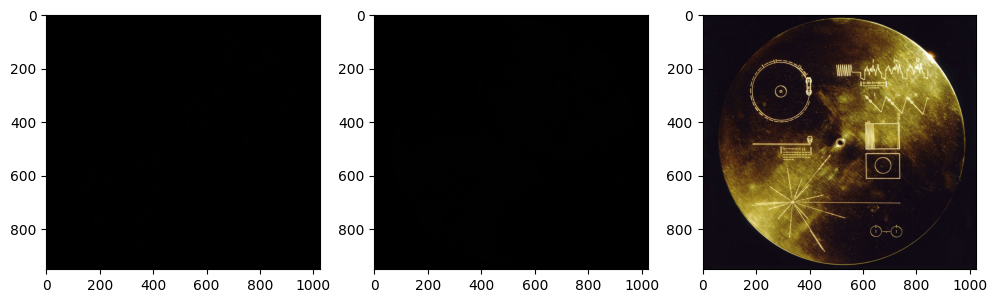

In [29]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.imshow(img_output)
ax2.imshow(img_output_denoised)
ax3.imshow(img)